In [1]:
# TODO: Install any packages that you might need
# For instance, you will need the smdebug package 
%pip install smdebug
%pip install seaborn
%pip install bokeh

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Notes/References:
https://pytorch.org/hub/pytorch_vision_resnet/
<br>All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

In [2]:
# TODO: Import any packages that you might need
# For instance you will need Boto3 and Sagemaker
import sagemaker
import boto3
import IPython

from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
)
from sagemaker.pytorch import PyTorch

import numpy as np
import pandas as pd

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import Image

import os
import random
import math

from sagemaker.debugger import Rule, ProfilerRule, rule_configs
from sagemaker.debugger import DebuggerHookConfig, ProfilerConfig, FrameworkProfile
from smdebug.profiler.analysis.notebook_utils.training_job import TrainingJob
from smdebug.profiler.analysis.notebook_utils.timeline_charts import TimelineCharts

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
[2024-12-24 21:20:01.671 default:2111 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None


## Dataset
TODO: Explain what dataset you are using for this project. Maybe even give a small overview of the classes, class distributions etc that can help anyone not familiar with the dataset get a better understand of it.

In [3]:
#TODO: Fetch and upload the data to AWS S3

# Command to download and unzip data
# !wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
!wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip --no-check-certificate

--2024-12-21 22:18:32--  https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 52.219.221.16, 52.219.120.16, 52.219.220.96, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|52.219.221.16|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1132023110 (1.1G) [application/zip]
Saving to: ‘dogImages.zip.1’

dogImages.zip.1     100%[===================>]   1.05G  41.0MB/s    in 26s     

2024-12-21 22:18:59 (41.2 MB/s) - ‘dogImages.zip.1’ saved [1132023110/1132023110]



In [4]:
!unzip -o dogImages.zip 


Archive:  dogImages.zip
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00003.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00023.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00036.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00047.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00048.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00058.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00071.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00078.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00116.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00125.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00139.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00141.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afghan_hound_00143.jpg  
  inflating: dogImages/test/002.Afghan_hound/Afgha

## Create the label file
Read the image folder and create the manifest/annotation/label file, for model training


In [17]:
dir_path = "dogImages"
d = {}
for dirpath, dirnames, filenames in os.walk(dir_path):
    # print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
    # print("{}: {} : {}".format(dirpath, dirnames, filenames))
    if  filenames:
        # print("{}:   {}".format(dirpath,   filenames))
        d[dirpath] = filenames

# pd.DataFrame.from_dict(d, orient='index')
df=pd.DataFrame(pd.Series(d).reset_index()).rename(columns={0: 'names'}).explode('names')

df.head()

,index,names
0,dogImages/test/001.Affenpinscher,Affenpinscher_00003.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00023.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00036.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00047.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00048.jpg


In [4]:
df[df['index'].str.contains("Airedale_terrier")].to_csv('temp.csv')

In [5]:
train_classes = len(df[df['index'].str.contains('train')].groupby(['index'])) #.count() #.count().to_csv('temp.csv')
test_classes  = len(df[df['index'].str.contains('test')].groupby(['index'])) #.count() #.count().to_csv('temp.csv')
valid_classes = len(df[df['index'].str.contains('valid')].groupby(['index'])) #.count() #.count().to_csv('temp.csv')

print(f"Count of \nTrain Classes: {train_classes}, \nTest Classes: {test_classes}, \nValidation Classes: {valid_classes}")

Count of 
Train Classes: 133, 
Test Classes: 133, 
Validation Classes: 133


### lets inspect some of the training images 

In [18]:
df.head()

,index,names
0,dogImages/test/001.Affenpinscher,Affenpinscher_00003.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00023.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00036.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00047.jpg
0,dogImages/test/001.Affenpinscher,Affenpinscher_00048.jpg


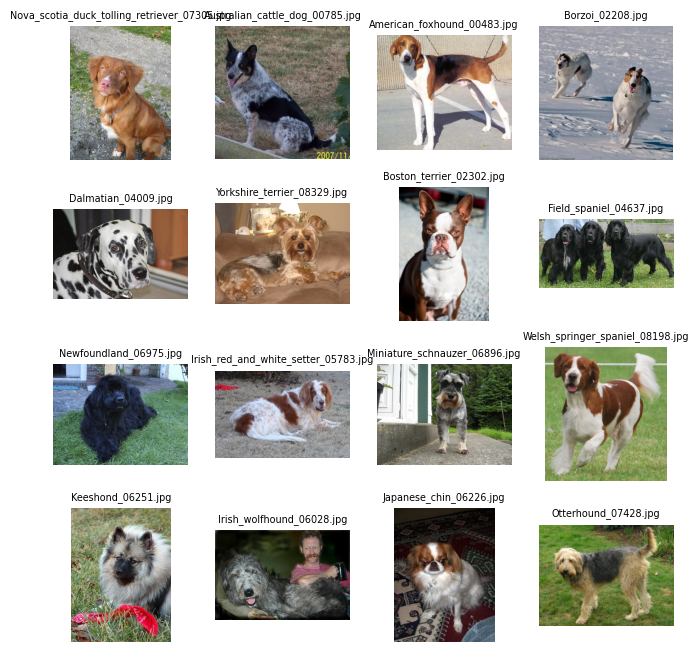

In [7]:
displayImages = 16
rows = cols = int(math.sqrt(displayImages))

df_train = df[df['index'].str.contains('train')]

totalImages = len(df_train)

fig, ax = plt.subplots(rows, cols , figsize=(8, 8) )
for i in range(displayImages):
    idx = random.randint(0,totalImages)

    path = df_train.iloc[idx]['index']
    name = df_train.iloc[idx]['names']
    filename = path+"/"+name

    image = plt.imread(filename)

    ax[i//rows, i%cols].imshow(image)
    ax[i//rows, i%cols].axis('off') 
    ax[i//rows, i%cols].set_title(name, fontsize='x-small')



In [8]:
train_summary=df_train['index'].str.rsplit('/', expand=True, n=1)[1].value_counts()


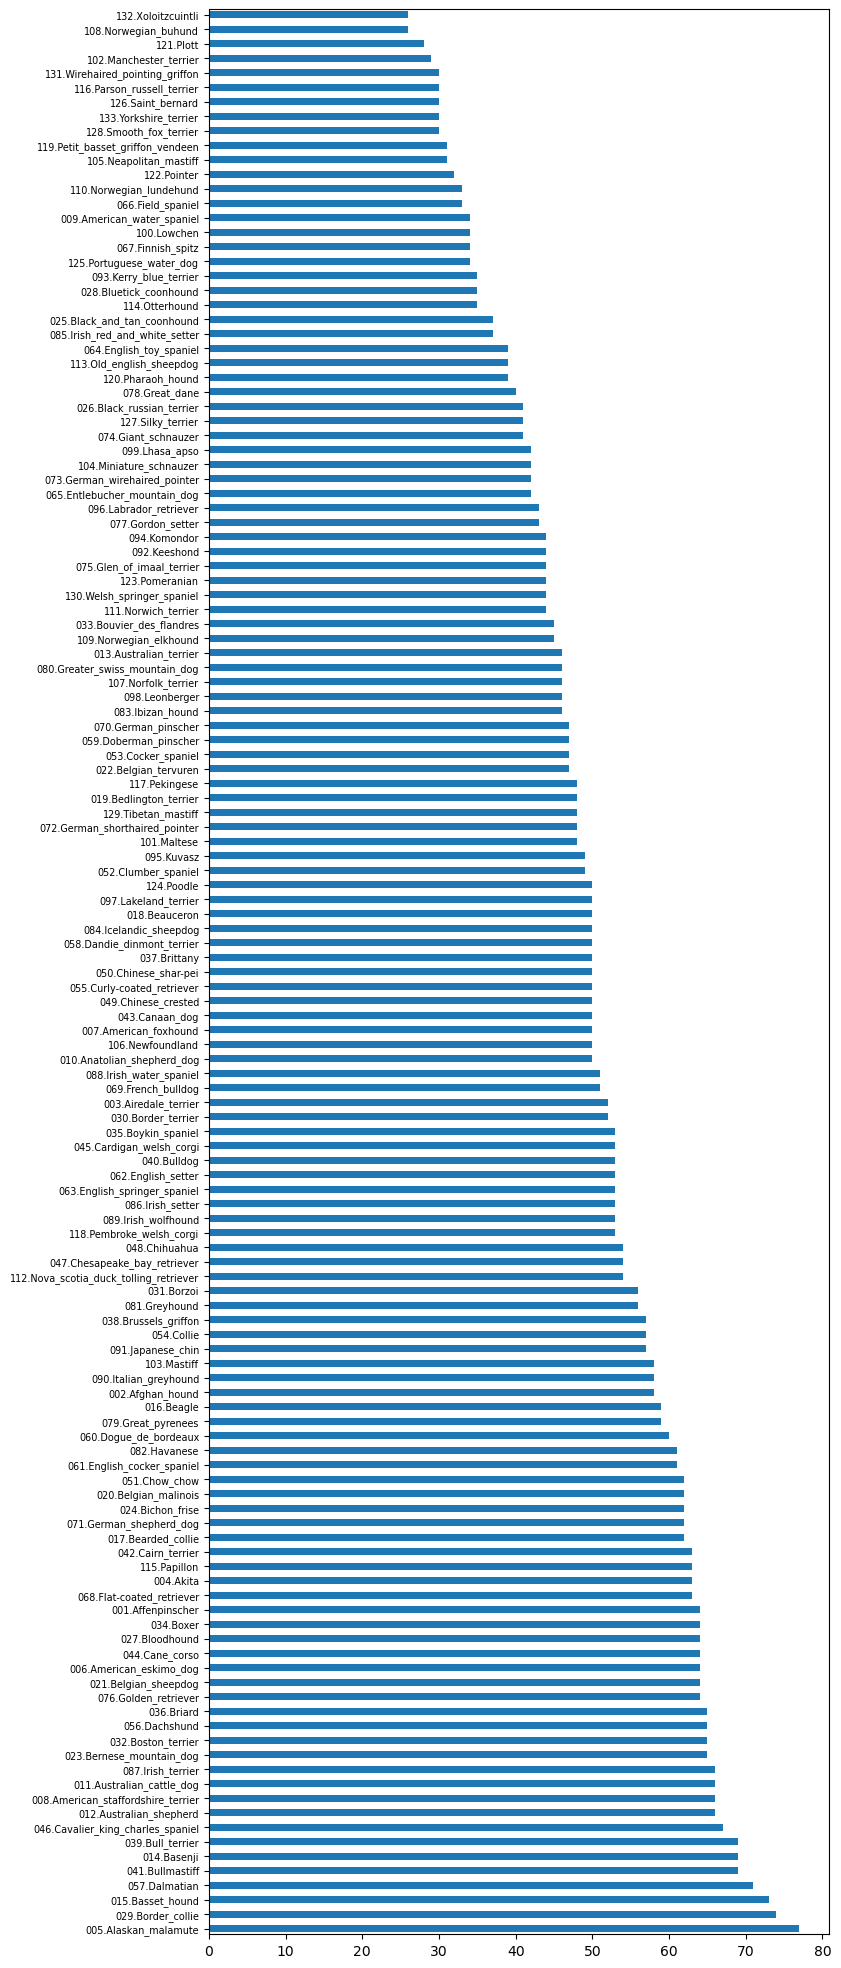

In [9]:
fig, ax = plt.subplots(figsize=(8,25), dpi=100)

hbars = ax.barh(y = train_summary.index, 
               width = train_summary,
               height = .5, )
plt.margins(y=.001)
plt.yticks( fontsize='x-small')

plt.show()

### Sagemaker


In [10]:
sagemaker_session = sagemaker.Session()

bucket = sagemaker_session.default_bucket()
prefix = "sagemaker/Image_classification"

role = sagemaker.get_execution_role()

print(f"Bucket  : {bucket}")
print(f"Session : {sagemaker_session}")
print(f"role    : {role}")

Bucket  : sagemaker-us-east-1-559647231942
Session : <sagemaker.session.Session object at 0x7f9817fc3b90>
role    : arn:aws:iam::559647231942:role/service-role/AmazonSageMaker-ExecutionRole-20240713T213821


In [13]:
# Temporary commented. Its needed to upload the images to S3

s3_data_location = sagemaker_session.upload_data(path="dogImages", bucket=bucket, key_prefix=prefix)

In [11]:
s3_data_location = "s3://sagemaker-us-east-1-559647231942/sagemaker/Image_classification"
path = s3_data_location + "/" + "path"
print(path)

s3://sagemaker-us-east-1-559647231942/sagemaker/Image_classification/path


## Hyperparameter Tuning
**TODO:** This is the part where you will finetune a pretrained model with hyperparameter tuning. Remember that you have to tune a minimum of two hyperparameters. However you are encouraged to tune more. You are also encouraged to explain why you chose to tune those particular hyperparameters and the ranges.

**Note:** You will need to use the `hpo.py` script to perform hyperparameter tuning.

In [12]:
#TODO: Declare your HP ranges, metrics etc.


hyperparameter_ranges = {
    "lr"         : ContinuousParameter(0.001, 0.1),
    "batch-size" : CategoricalParameter([32, 64, 128]),
    "epochs"     : IntegerParameter(10, 20)
}


objective_metric_name = "Accuracy"
objective_type = "Maximize"
metric_definitions = [{"Name": "Accuracy", "Regex": "Test set: Accuracy: ([0-9\\.]+)"}]


In [13]:
#TODO: Create estimators for your HPs

# estimator = # TODO: Your estimator here
estimator = PyTorch(
    entry_point="hpo.py",
    role=role,
    py_version='py36',
    framework_version="1.8",
    instance_count=1,
    instance_type="ml.g4dn.xlarge"   #ml.m5.large"  #ml.g4dn.2xlarge
)


# tuner = # TODO: Your HP tuner here
tuner = HyperparameterTuner(
    estimator,
    objective_metric_name,
    hyperparameter_ranges,
    metric_definitions,
    max_jobs=1,
    max_parallel_jobs=1,
    objective_type=objective_type,
)

In [14]:
# def setOSenvironment():
#     os.environ['SM_CHANNEL_TRAIN'] = s3_train_location  # s3_data_location + "/train/"
#     os.environ['SM_CHANNEL_VAL']   = s3_val_location    # s3_data_location + "/valid/"
#     os.environ['SM_CHANNEL_TEST']  = s3_test_location   # s3_data_location + "/test/"
#     os.environ['SM_MODEL_DIR']     = s3_data_location + "/model/"
#     # os.environ['NUM_CLASSES']      =  str(train_classes)

In [1]:
# TODO: Fit your HP Tuner
# tuner.fit() # TODO: Remember to include your data channels


s3_train_location = s3_data_location + "/train/"
s3_val_location   = s3_data_location + "/valid/"
s3_test_location  = s3_data_location + "/test/"

os.environ['SM_CHANNEL_TRAIN'] = s3_train_location  # s3_data_location + "/train/"
os.environ['SM_CHANNEL_VAL']   = s3_val_location    # s3_data_location + "/valid/"
os.environ['SM_CHANNEL_TEST']  = s3_test_location   # s3_data_location + "/test/"
os.environ['SM_MODEL_DIR']     = s3_data_location + "/model/"
# os.environ['NUM_CLASSES']      =  str(train_classes)


tuner.fit({ 'train': s3_train_location   ,
            'test' : s3_test_location    ,
            'val'  : s3_val_location   
            }, wait=True)

# TODO: Remember to include your data channels

NameError: name 's3_data_location' is not defined

In [52]:
# TODO: Get the best estimators and the best HPs

best_estimator = tuner.best_estimator() #TODO

#Get the hyperparameters of the best trained model
best_estimator.hyperparameters()

hyperparameters = { "lr"        :     best_estimator.hyperparameters()['lr'],
                    "batch-size":  (best_estimator.hyperparameters()['batch-size'].replace('"', '')), 
                    "epochs"    :     best_estimator.hyperparameters()['epochs']
                   }
hyperparameters


2024-12-24 16:49:38 Starting - Preparing the instances for training
2024-12-24 16:49:38 Downloading - Downloading the training image
2024-12-24 16:49:38 Training - Training image download completed. Training in progress.
2024-12-24 16:49:38 Uploading - Uploading generated training model
2024-12-24 16:49:38 Completed - Resource released due to keep alive period expiry


{'lr': '0.0012479081569857305', 'batch-size': '128', 'epochs': '18'}

In [87]:
best_estimator.

AttributeError: 'str' object has no attribute 'data'

In [53]:
best_estimator.hyperparameters()

{'_tuning_objective_metric': '"Accuracy"',
 'batch-size': '"128"',
 'epochs': '18',
 'lr': '0.0012479081569857305',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"pytorch-training-2024-12-24-16-11-25-368"',
 'sagemaker_program': '"hpo.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-16-11-25-368/source/sourcedir.tar.gz"'}

In [54]:
print(hyperparameters)

{'lr': '0.0012479081569857305', 'batch-size': '128', 'epochs': '18'}


## Model Profiling and Debugging
TODO: Using the best hyperparameters, create and finetune a new model

**Note:** You will need to use the `train_model.py` script to perform model profiling and debugging.

In [55]:
# TODO: Set up debugging and profiling rules and hooks


# Set up debugging and profiling rules and hooks
rules = [
    Rule.sagemaker(rule_configs.vanishing_gradient()),
    Rule.sagemaker(rule_configs.overfit()),
    Rule.sagemaker(rule_configs.overtraining()),
    Rule.sagemaker(rule_configs.poor_weight_initialization()),
    Rule.sagemaker(rule_configs.loss_not_decreasing()),
    ProfilerRule.sagemaker(rule_configs.LowGPUUtilization()),
    ProfilerRule.sagemaker(rule_configs.ProfilerReport())
]

# create debugger and profiler configurations
hook_config = DebuggerHookConfig(
    hook_parameters={"train.save_interval": "100", 
                     "eval.save_interval" : "10"}
)
profiler_config = ProfilerConfig(
    system_monitor_interval_millis=500, framework_profile_params=FrameworkProfile(num_steps=10)
)


See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [37]:
s3_train_location

's3://sagemaker-us-east-1-559647231942/sagemaker/Image_classification/train/'

In [38]:
# os.environ['SM_CHANNEL_TRAIN'] = s3_train_location  # s3_data_location + "/train/"
# os.environ['SM_CHANNEL_VAL']   = s3_val_location    # s3_data_location + "/valid/"
# os.environ['SM_CHANNEL_TEST']  = s3_test_location   # s3_data_location + "/test/"
# os.environ['SM_MODEL_DIR']     = s3_data_location + "/model/"
#     # os.environ['NUM_CLASSES']      =  str(train_classes)

In [56]:
# TODO: Create and fit an estimator

# estimator = # TODO: Your estimator here

# setOSenvironment()

estimator = PyTorch(
    entry_point="train_model.py",
    role=role,
    py_version='py36',
    framework_version="1.8",
    instance_count=1,
    instance_type="ml.g4dn.xlarge",
    hyperparameters=hyperparameters,
    profiler_config=profiler_config,
    rules=rules,
    debugger_hook_config=hook_config
)

estimator.fit({ 'train': s3_train_location   ,
            'test' : s3_test_location    ,
            'val'  : s3_val_location   
            }, wait=True)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.


INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.i

2024-12-24 19:40:53 Starting - Starting the training job...
2024-12-24 19:41:22 Starting - Preparing the instances for trainingVanishingGradient: InProgress
Overfit: InProgress
Overtraining: InProgress
PoorWeightInitialization: InProgress
LossNotDecreasing: InProgress
LowGPUUtilization: InProgress
ProfilerReport: InProgress
...
2024-12-24 19:41:42 Downloading - Downloading input data......
2024-12-24 19:42:43 Downloading - Downloading the training image..................
2024-12-24 19:45:51 Training - Training image download completed. Training in progress...bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2024-12-24 19:46:06,071 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2024-12-24 19:46:06,101 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2024-12-24 19:46:06,105 sagemaker_pytorch_container.training INFO     Invoking user training sc

In [57]:
# TODO: Plot a debugging output.
from smdebug.trials import create_trial
from smdebug.core.modes import ModeKeys

trial = create_trial(estimator.latest_job_debugger_artifacts_path())

[2024-12-24 20:28:39.763 default:461 INFO s3_trial.py:42] Loading trial debug-output at path s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/debug-output


In [58]:
trial.tensor_names()

[2024-12-24 20:28:51.532 default:461 INFO trial.py:197] Training has ended, will refresh one final time in 1 sec.
[2024-12-24 20:28:52.549 default:461 INFO trial.py:210] Loaded all steps


['NLLLoss_output_0',
 'gradient/ResNet_fc.0.bias',
 'gradient/ResNet_fc.0.weight',
 'gradient/ResNet_fc.2.bias',
 'gradient/ResNet_fc.2.weight',
 'gradient/ResNet_fc.4.bias',
 'gradient/ResNet_fc.4.weight',
 'gradient/ResNet_fc.6.bias',
 'gradient/ResNet_fc.6.weight',
 'layer1.0.relu_input_0',
 'layer1.0.relu_input_1',
 'layer1.0.relu_input_2',
 'layer1.1.relu_input_0',
 'layer1.1.relu_input_1',
 'layer1.1.relu_input_2',
 'layer1.2.relu_input_0',
 'layer1.2.relu_input_1',
 'layer1.2.relu_input_2',
 'layer2.0.relu_input_0',
 'layer2.0.relu_input_1',
 'layer2.0.relu_input_2',
 'layer2.1.relu_input_0',
 'layer2.1.relu_input_1',
 'layer2.1.relu_input_2',
 'layer2.2.relu_input_0',
 'layer2.2.relu_input_1',
 'layer2.2.relu_input_2',
 'layer2.3.relu_input_0',
 'layer2.3.relu_input_1',
 'layer2.3.relu_input_2',
 'layer3.0.relu_input_0',
 'layer3.0.relu_input_1',
 'layer3.0.relu_input_2',
 'layer3.1.relu_input_0',
 'layer3.1.relu_input_1',
 'layer3.1.relu_input_2',
 'layer3.2.relu_input_0',
 'l

In [62]:
len(trial.tensor("NLLLoss_output_0").steps(mode=ModeKeys.TRAIN))

2

In [64]:
len(trial.tensor("NLLLoss_output_0").steps(mode=ModeKeys.EVAL))

1

In [65]:
def get_data(trial, tname, mode):
    tensor = trial.tensor(tname)
    steps = tensor.steps(mode=mode)
    vals = []
    for s in steps:
        vals.append(tensor.value(s, mode=mode))
    return steps, vals

In [66]:
from mpl_toolkits.axes_grid1 import host_subplot


def plot_tensor(trial, tensor_name):

    steps_train, vals_train = get_data(trial, tensor_name, mode=ModeKeys.TRAIN)
    print("loaded TRAIN data")
    steps_eval, vals_eval = get_data(trial, tensor_name, mode=ModeKeys.EVAL)
    print("loaded EVAL data")

    fig = plt.figure(figsize=(10, 7))
    host = host_subplot(111)

    par = host.twiny()

    host.set_xlabel("Steps (TRAIN)")
    par.set_xlabel("Steps (EVAL)")
    host.set_ylabel(tensor_name)

    (p1,) = host.plot(steps_train, vals_train, label=tensor_name)
    print("completed TRAIN plot")
    (p2,) = par.plot(steps_eval, vals_eval, label="val_" + tensor_name)
    print("completed EVAL plot")
    leg = plt.legend()

    host.xaxis.get_label().set_color(p1.get_color())
    leg.texts[0].set_color(p1.get_color())

    par.xaxis.get_label().set_color(p2.get_color())
    leg.texts[1].set_color(p2.get_color())

    plt.ylabel(tensor_name)

    plt.show()

loaded TRAIN data
loaded EVAL data
completed TRAIN plot
completed EVAL plot


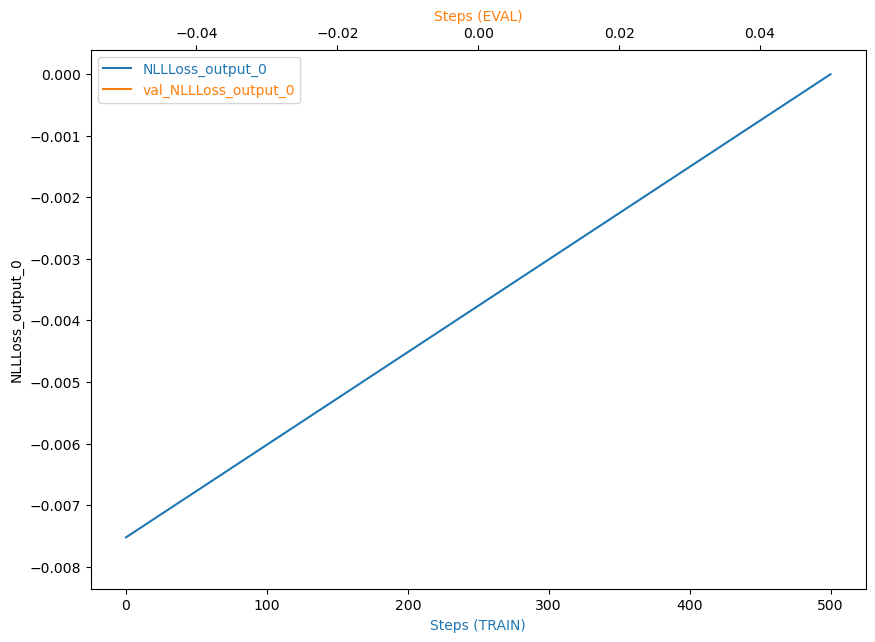

In [67]:
plot_tensor(trial, "NLLLoss_output_0")

**TODO**: Is there some anomalous behaviour in your debugging output? If so, what is the error and how will you fix it?  
**TODO**: If not, suppose there was an error. What would that error look like and how would you have fixed it?

In [68]:
# TODO: Display the profiler output
rule_output_path = estimator.output_path + estimator.latest_training_job.job_name + "/rule-output"

In [69]:
! aws s3 ls {rule_output_path} --recursive

2024-12-24 20:20:33     429964 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-report.html
2024-12-24 20:20:32     287417 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb
2024-12-24 20:20:26        192 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json
2024-12-24 20:20:27     104235 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-reports/CPUBottleneck.json
2024-12-24 20:20:27       1959 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-reports/Dataloader.json
2024-12-24 20:20:27        328 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-reports/GPUMemoryIncrease.json
2024-12-24 20:20:27       4555 pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-re

In [70]:
! aws s3 cp {rule_output_path} ./ --recursive

download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json to ProfilerReport/profiler-output/profiler-reports/BatchSize.json
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-reports/CPUBottleneck.json to ProfilerReport/profiler-output/profiler-reports/CPUBottleneck.json
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb to ProfilerReport/profiler-output/profiler-report.ipynb
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerReport/profiler-output/profiler-report.html to ProfilerReport/profiler-output/profiler-report.html
download: s3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/rule-output/ProfilerRepor

In [71]:
# import os

# get the autogenerated folder name of profiler report
profiler_report_name = [
    rule["RuleConfigurationName"]
    for rule in estimator.latest_training_job.rule_job_summary()
    if "Profiler" in rule["RuleConfigurationName"]
][0]

In [74]:
IPython.display.HTML(filename=profiler_report_name + "/profiler-output/profiler-report.html")

## Model Deploying

In [85]:
latest_job = f"s3://{bucket}/{estimator.latest_training_job.job_name}/output/model.tar.gz"
latest_job

's3://sagemaker-us-east-1-559647231942/pytorch-training-2024-12-24-19-40-47-222/output/model.tar.gz'

In [81]:
estimator.latest_training_job.job_name
# .output_path + estimator_debug.latest_training_job.job_name + "/rule-output"
# estimator.latest_job_tensorboard_artifacts_path.path()

'pytorch-training-2024-12-24-19-40-47-222'

In [ ]:
# TODO: Deploy your model to an endpoint

predictor=estimator.deploy() # TODO: Add your deployment configuration like instance type and number of instances

In [ ]:
# TODO: Run an prediction on the endpoint

image = # TODO: Your code to load and preprocess image to send to endpoint for prediction
response = predictor.predict(image)

In [ ]:
# TODO: Remember to shutdown/delete your endpoint once your work is done
predictor.delete_endpoint()